In [1]:
''' Project 2: Movie Ratings Analysis Using NumPy, Pandas, and Matplotlib

Objective:
Analyze and visualize a movie dataset to understand trends in ratings and relationships between features using NumPy, Pandas, and Matplotlib.
Create the project on google colab and paste the link
Google Colab: Platform Link

Note: Dataset can be download using Kaggle or ChatGPT

Key Tasks:
1. Load and Inspect Data
      Load the dataset using Pandas.
      Preview the data and check for missing values.

2. Data Cleaning
      Drop or fill missing data to prepare for analysis.

3. Statistical Analysis with NumPy
      Compute mean, median, and standard deviation of movie ratings.
      Perform similar analysis on budget and revenue if needed.

4. Grouped Analysis with Pandas
      Group by Genre and compute average ratings.
      Group by Director to analyze average rating per director.
      Group by Year to analyze rating trends over time.

5. Visualizations with Matplotlib
      Bar Plot: Show average rating by genre and by director.
      Line Plot: Display average ratings over years.
      Scatter Plot: Budget vs. Rating, Revenue vs. Rating.
      Horizontal Bar Plot: Top-rated movies by rating.
'''

' Project 2: Movie Ratings Analysis Using NumPy, Pandas, and Matplotlib\n\nObjective:\nAnalyze and visualize a movie dataset to understand trends in ratings and relationships between features using NumPy, Pandas, and Matplotlib.\nCreate the project on google colab and paste the link\nGoogle Colab: Platform Link\n\nNote: Dataset can be download using Kaggle or ChatGPT\n\nKey Tasks:\n1. Load and Inspect Data\n      Load the dataset using Pandas.\n      Preview the data and check for missing values.\n\n2. Data Cleaning\n      Drop or fill missing data to prepare for analysis.\n\n3. Statistical Analysis with NumPy\n      Compute mean, median, and standard deviation of movie ratings.\n      Perform similar analysis on budget and revenue if needed.\n\n4. Grouped Analysis with Pandas\n      Group by Genre and compute average ratings.\n      Group by Director to analyze average rating per director.\n      Group by Year to analyze rating trends over time.\n\n5. Visualizations with Matplotlib\n 

In [2]:
from google.colab import drive   # Import Google Drive module

drive.mount('/content/drive')    # Connect Google Drive to Colab,  give access to Google Drive.

Mounted at /content/drive


Undo a Deleted CellIf you accidentally deleted an entire code or text block, you can restore it using

 **Windows / Linux: Press Ctrl + M, then press Z.**

# Data Analysis Lifecycle has series of steps:

1. **Define the Problem:** Analyze movie ratings and identify trends.
2. **Collect Data:** Load the movie dataset into Pandas.
3. **Explore Data:** Use head(), info(), describe(), and isnull().
4. **Clean Data:** Handle missing values using dropna() or fillna().
5. **Statistical Analysis:** Calculate mean, median, standard deviation, and group by genre, director, and year.
6. **Visualize Data:** Visualized bar plots, line plots, scatter plots, and horizontal bar plots.
7. **Interpret Results:** Identify popular genres, top directors, and relationships between budget, revenue, and ratings.
8. **Make Decisions:** Recommend genres, directors, and budgeting strategies based on the insights.

# 1. Define the Problem:

The Aim of this project is to perform data analysis on movie ratings dataset using Python libraries such as NumPy, Pandas, and Matplotlib. The project aims to discover meaningful patterns in movie ratings with regard to budgets, revenues, genres, directors, and release years through statistical analysis and data visualization.

**Dataset Info:**

Dataset Name: Movie_Ratings_Analysis derived from ChatGPT in the csv format.

Number of Records: 5000 Data entries from 2000-2025

Columns: Movie_Title, Genre, Director, Year, Rating, Budget_Million_USD, Revenue_Million_USD.




# 2. Collect Data:

First, I imported the required Python libraries. Pandas is used for data manipulation, NumPy for statistical(Mathematical) array calculations, and Matplotlib for creating visualizations.

I loaded the Movie_Ratings_Analysis dataset stored as a CSV file into a Pandas DataFrame. A DataFrame is a tabular data structure in Pandas that stores data in rows and columns. It allows us to efficiently organize, manipulate, analyze, and visualize structured data.

In [3]:
# Import Pandas library for data manipulation
import pandas as pd                    # Used to read, clean, and analyze data, give it the alias pd

# Read CSV file from Google Drive
df = pd.read_csv('/content/drive/My Drive/Project_2_Movie_Ratings_Analysis/Project_2_Movie_Ratings_Analysis.csv')
#Movie_Ratings_Analysis dataset stored in df

# 3. Explore Data:

Attribute: Stores or returns information about an object.

Method: Performs an action on an object.

Using print() displays it clearly. for `df.shape`, `df.columns`, are attributes, returns values so we use `print()`, otherwise tabular format will appaear

whereas `df.info()` method already displays the dataset information and returns None, so using print(df.info()) prints the information followed by None, which is unnecessary.

In [4]:
df.head()  # A method to display first 5 rows of the dataset by default

,Movie_Title,Genre,Director,Year,Rating,Budget_Million_USD,Revenue_Million_USD
0,Painting Yeah,Fantasy,Ronald Morales,2018,8.3,165.20,837.29
1,If Well,Sci-Fi,Brenda Johnson,2015,9.1,24.68,97.34
2,In Pattern,Romance,Raven Duncan,2013,2.4,229.61,872.00
3,Usually Upon,Action,Philip Morrison,2008,1.4,202.64,686.97
4,Charge Defense,Romance,David Downs,2014,8.3,7.71,846.87


In [5]:
print("========== Dataset Shape ==========")
print(df.shape)     # Display rows and columns

print("\n========== Column Names ==========") # The \n(a newline character)It is used to insert a line break and print the following text on the next line., making the output easier to read.
print(df.columns)   # Display column names

print("\n========== Dataset Information ==========")
df.info()   # Display data types and non-null values. so that we can verify or correct datatypes

========== Dataset Shape ==========
(5000, 7)

========== Column Names ==========
Index(['Movie_Title', 'Genre', 'Director', 'Year', 'Rating',
       'Budget_Million_USD', 'Revenue_Million_USD'],
      dtype='object')

========== Dataset Information ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Movie_Title          5000 non-null   object 
 1   Genre                5000 non-null   object 
 2   Director             5000 non-null   object 
 3   Year                 5000 non-null   int64  
 4   Rating               5000 non-null   float64
 5   Budget_Million_USD   5000 non-null   float64
 6   Revenue_Million_USD  5000 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 273.6+ KB


In the dtype, object is considered as Text/String

# 4. Clean Data:

* Missing values can produce incorrect statistical calculations and misleading visualizations.
* Replacing missing numerical values with the mean of their respective columns to preserve the dataset without losing records. while maintaining reasonable statistical properties. Deleting rows reduces the dataset size.

In [6]:
df.isnull().sum()   # Count missing values in each column

,0
Movie_Title,0
Genre,0
Director,0
Year,0
Rating,0
Budget_Million_USD,0
Revenue_Million_USD,0


# 5. Statistical Analysis:

**np used here to generate a single summary unit**

**Movie Rating Statistics**

Mean Rating: First, I calculated the mean rating using in-built function, which gives the average movie rating(adding all the movie ratings and dividing by the total number of movies), rounded to two decimal places. This helps in understanding the overall audience reception of the movies in the dataset. I stored the result in a variable called mean_rating.

Median Rating: Next, I calculated the **median rating** using in-built function, which is the middle rating value after sorting all movie ratings in ascending order. The median is useful because it is less affected by extremely high or low ratings, making it a better representation of the typical movie rating, rounded to two decimal places. I stored the result in a variable called median_rating.

Finally, I calculated the **standard deviation of ratings** using in-built function, which measures how much the movie ratings vary from the average rating, rounded to two decimal places. A higher standard deviation indicates that the ratings are more spread out, while a lower value suggests that the ratings are more consistent across movies. I stored the result in a variable called std_rating.

I used print() to display the results, f-strings to insert the variable values into the text. and / 10 indicates that the rating is measured on a scale of 10. for mran and median. and rating points indicates that the value represents the variability in movie ratings for standard deviation.

In [7]:
# Import NumPy library for numerical calculations like for mean, median, standard deviation, give it the alias np
import numpy as np

#Movie Rating Statistics
mean_rating = round(np.mean(df['Rating']),2)      # Calculated rounded average rating
median_rating = round(np.median(df['Rating']),2)  # Calculated rounded median rating
std_rating = round(np.std(df['Rating']),2)        # Calculated rounded standard deviation

print(f"Average Rating (Mean): {mean_rating} / 10 points")
print(f"Median Rating: {median_rating} / 10 points")
print(f"Standard Deviation: {std_rating} rating points")

Average Rating (Mean): 5.5 / 10 points
Median Rating: 5.5 / 10 points
Standard Deviation: 2.61 rating points


**Interpretation:**

The average movie rating is 5.5/10. Since the mean and median are equal, the ratings are evenly distributed. The standard deviation of 2.61 shows that ratings vary moderately around the average.

**Budget Statistics**

Mean Budget: First, I calculated the mean budget using in-built function, which gives the average budget of all movies by summing all budget values and dividing by the total number of movies, rounded to two decimal places.This provides an overview of how much was typically spent on movie production. I stored the result in a variable called mean_budget and displayed it in million USD.

Median Budget: Next, I calculated the median budget using in-built function, which is the middle budget value after sorting all movie budgets in ascending order, rounded to two decimal places. The median budget is useful because it is less influenced by movies with exceptionally high or low budgets, providing a better representation of a typical movie budget. I stored the result in a variable called median_budget and displayed it in million USD, rounded to two decimal places.

Finally, I calculated the standard deviation of budgets using in-built function, which indicates how much movie budgets differ from the average budget, rounded to two decimal places. A higher standard deviation suggests a larger variation in production costs, while a lower value indicates that most movie budgets are relatively similar. I stored the result in a variable called std_budget and displayed it in million USD, rounded to two decimal places.

I used print() to display the results, f-strings to insert the variable values into the text, $ represents US dollars, and Million indicates that the value in movie budgets.

In [8]:
#Budget Statistics
mean_budget = round(np.mean(df['Budget_Million_USD']),2)      # rounded Average budget
median_budget = round(np.median(df['Budget_Million_USD']),2) # rounded Median budget
std_budget = round(np.std(df['Budget_Million_USD']),2)       # rounded Standard deviation of budget

print(f"Average Budget (Mean): ${mean_budget} Million")
print(f"Median Budget: ${median_budget} Million")
print(f"Standard Deviation: ${std_budget} Million")

Average Budget (Mean): $152.25 Million
Median Budget: $150.41 Million
Standard Deviation: $84.33 Million


**Interpretation:**

Since Mean is nearer to median. The std deviation is 84.33 MIllion USD. So most Movie budget within 68M to 237M USD(152.25 ± 84.33M USD)

**Revenue Statistics**

Mean Revenue: First, I calculated the mean revenue using in-built function, which gives the average revenue generated by all movies by adding the revenue values of all movies and dividing by the total number of movies and rounded to two decimal places This helps in understanding the overall financial performance of movies in the dataset. I stored the result in a variable called mean_revenue.


Median Revenue: Next, I calculated the median revenue using in-built function, which is the middle revenue value after sorting all revenue values in ascending order, rounded to two decimal places. The median is useful because it is less affected by movies with exceptionally high or low revenues, making it a better indicator of the typical movie revenue. I stored the result in a variable called median_revenue.

Finally, I calculated the standard deviation of revenue using in-built function, which measures how much movie revenues fluctuate from the average revenue, rounded to two decimal places. A higher value indicates a greater difference in movie earnings, while a lower value suggests that revenues are more consistent across movies. I stored the result in a variable called std_revenue.

I used print() to display the results, f-strings to insert the variable values into the text, $ represents US dollars, and Million indicates that the value in movie budgets.



In [9]:
# Revenue Statistics
mean_revenue = round(np.mean(df['Revenue_Million_USD']),2)      # rounded Average revenue
median_revenue = round(np.median(df['Revenue_Million_USD']),2)  # rounded Median revenue
std_revenue = round(np.std(df['Revenue_Million_USD']),2)        # rounded Standard deviation of revenue

print(f"Average Revenue (Mean): ${mean_revenue} Million")
print(f"Median Revenue: ${median_revenue} Million")
print(f"Revenue Variability (Standard Deviation): ${std_revenue} Million")

Average Revenue (Mean): $499.76 Million
Median Revenue: $494.38 Million
Revenue Variability (Standard Deviation): $285.97 Million


**Interpretation:**

Since Mean is nearer to median. The std deviation is $ 285.97M. $214M to $786M ($499.76M ± 285.97M USD)

**Grouped Analysis by Genre**

First, I grouped the dataset by Genre and calculated the average rating for each genre and rounded the average ratings to two decimal places for better readability. This helps identify which movie genres tend to receive higher or lower ratings from audiences. I stored the results in a variable called genre_rating.

df(pandas) used here to generate a DataFrame

When do we use () vs []?
| Symbol | Used For                            | Example                                             |
| ------ | ----------------------------------- | --------------------------------------------------- |
| `()`   | Calling a function or method        | `groupby('Genre')`, `mean()`, `round(2)`            |
| `[]`   | Selecting a column, row, or element | `df['Rating']`, `df[['Genre','Rating']]`, `list[0]` |


In [10]:
# Group by Genre and compute average ratings.
genre_rating = df.groupby('Genre')['Rating'].mean().round(2)  # Group by genre and compute average rating
print(genre_rating)

Genre
Action       5.43
Adventure    5.51
Animation    5.62
Comedy       5.43
Drama        5.55
Fantasy      5.43
Horror       5.36
Romance      5.56
Sci-Fi       5.61
Thriller     5.53
Name: Rating, dtype: float64


## 6. Visualize Data, Interpret Results, Make Decisions:

**Bar Plot – Average Rating by Genre**

First, I imported the Matplotlib library, which is used to create graphs and visualize data. I gave it the alias plt to write shorter and cleaner code.

Next, I created a figure with a size of 8 × 5 inches using figure(figsize=(8,5)) to ensure that the bar chart is clear and easy to read.

After that, I used the bar() function to create a bar chart. The X-axis represents the different movie genres, and the Y-axis represents their corresponding average ratings. This visualization helps compare the ratings of different genres and identify which genres tend to receive higher or lower ratings.

Then, I added a title using title() and labeled both axes using xlabel() and ylabel() so that the chart is easy to understand.

Next, I rotated the X-axis labels vertically using xticks(rotation=90) to prevent the genre names from overlapping and to improve readability.

Finally, I displayed the bar chart using the show() function, which allowed me to visually compare the average ratings across all movie genres.

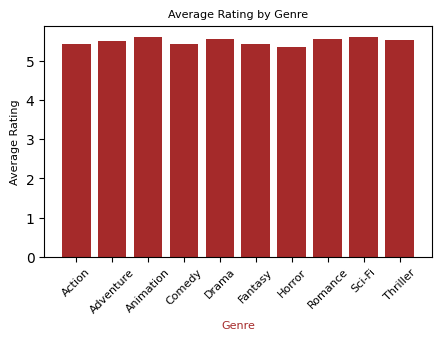

In [11]:
# Import Matplotlib library for plotting graphs
import matplotlib.pyplot as plt        # Used to create charts and visualizations, gave it the alias plt to write shorter code.

#Bar Plot – Average Rating by genre
plt.figure(figsize=(5,3))  # create a figure with a size of 8 × 5 inches
plt.bar(genre_rating.index, genre_rating.values, color='brown')  # X-axis represents Genres, Y-axis: Average Ratings

plt.title('Average Rating by Genre', fontsize=8)  # Add title
plt.xlabel('Genre', fontsize=8, color='brown')  # X-axis label
plt.xticks(rotation=45, fontsize=8)  # Rotate X-axis labels vertically
plt.ylabel('Average Rating', fontsize=8)  # Y-axis label
plt.show()  # Display plot

#Business Insights

* Genres like Animation and Sci-Fi have higher average ratings than others(~5.65).
* This shows that audiences prefer certain types of movies.
* Production companies can focus more on popular genres to attract more viewers.

**Grouped Analysis by Director**

Next, I grouped the dataset by Director and calculated the average rating for each director and rounded the average ratings to two decimal places for better readability. This helps identify which directors consistently produce highly-rated movies based on the dataset. I stored the results in a variable called director_rating.

In [12]:
#Average Rating by Director
director_rating = df.groupby('Director')['Rating'].mean().round(2)  # Group by director and compute average rating
print(director_rating)

Director
Aaron Mooney         5.26
Adam Nguyen          5.07
Adrian Martinez      4.38
Alejandro Fleming    6.04
Alexandra Lewis      5.74
                     ... 
Valerie Cook         5.28
Victor Manning       5.04
Wendy Hunter         5.98
Wesley Brown         6.52
Zachary Simpson      5.57
Name: Rating, Length: 200, dtype: float64


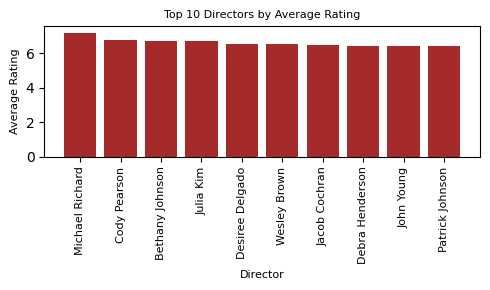

In [13]:
# Bar Plot – Average Rating by Director
# Top 10 directors by average rating

top_directors = director_rating.sort_values(ascending=False).head(10) # Sort directors by average rating (highest to lowest) and select the top 10

plt.figure(figsize=(5, 3))# Create a figure with width=5 inches and height=3 inches
plt.bar(top_directors.index, top_directors.values, color='brown')  # Plot bar chart (X-axis: Director names, Y-axis: Average ratings)

plt.title('Top 10 Directors by Average Rating', fontsize=8)                         # Add chart title
plt.xlabel('Director', fontsize=8)                                                  # Label the X-axis
plt.ylabel('Average Rating', fontsize=8)                                            # Label the Y-axis
plt.xticks(rotation=90, fontsize=8)                                                 # Rotate X-axis labels by 45° for better readability
plt.tight_layout()                                                      # Automatically adjust spacing so labels are not cut off
plt.show()                                                              # Display the bar chart


# Business Insights

* The director Michael Richard consistently received higher ratings of ~ 7.5.
* Director performance can help studios choose the right person for future projects like Actors.

**Grouped Analysis by Year**

Finally, I grouped the dataset by Year and calculated the average movie rating for each year and rounded the average ratings to two decimal places for better readability. This helps identify rating trends over time and shows whether movies released in certain years received higher or lower average ratings. I stored the results in a variable called year_rating.

In [14]:
#Average Rating by Year
year_rating = df.groupby('Year')['Rating'].mean().round(2)  # Group by year and compute average rating
print(year_rating)

Year
2000    5.49
2001    4.98
2002    5.42
2003    5.78
2004    5.42
2005    5.94
2006    5.44
2007    5.58
2008    5.58
2009    5.31
2010    5.66
2011    5.29
2012    5.61
2013    5.40
2014    5.77
2015    5.45
2016    5.58
2017    5.71
2018    5.30
2019    5.18
2020    5.39
2021    5.71
2022    5.43
2023    5.61
2024    5.72
2025    5.36
Name: Rating, dtype: float64


**Line Plot – Average Ratings Over Years**

First, I created a figure with a size of 8 × 5 inches using figure(figsize=(8,5)) to make the line graph clear and easy to read.

Next, I used the plot() function to create a line graph from the year_rating data. The X-axis represents the movie release years, while the Y-axis represents the average ratings for each year. I also added circular markers (marker='o') to highlight each data point on the graph.

Then, I added a title using title() and labeled both axes using xlabel() and ylabel() so that the graph is easy to understand.

After that, I enabled grid lines using grid(True) to improve readability and make it easier to compare rating values across different years.

Finally, I displayed the line graph using the show() function, which allowed me to visualize the trend of average movie ratings over time and identify years with higher or lower ratings.

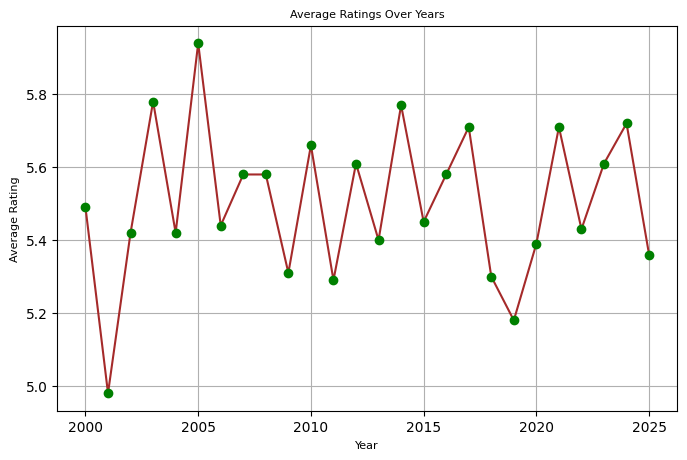

In [15]:
# Line Plot – Rating Trend Over Years

plt.figure(figsize=(8, 5))  # Set figure size

plt.plot(year_rating.index, year_rating.values, color='brown', marker='o', markerfacecolor="green",
         markeredgecolor="green")  # X-axis: Years, Y-axis: Average Ratings

plt.title('Average Ratings Over Years', fontsize=8)  # Add title
plt.xlabel('Year', fontsize=8)  # X-axis label
plt.ylabel('Average Rating', fontsize=8)  # Y-axis label

plt.grid(True)  # Display grid

plt.show()  # Display plot

# Business Insights

* 2005 got highest rating of 5.9 followed by 2002, 2014, 2021, 2024 with 5.7
* This shows that audience preferences can change over time.
* Movie producers should understand current trends before making new movies

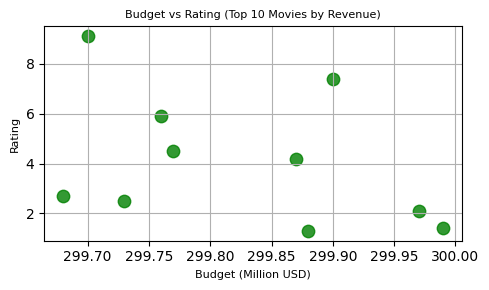

In [16]:
# Scatter Plot – Budget vs Rating (Top 10 Movies by Revenue)

# Select the top 10 movies with the highest revenue

top10_budget = df.sort_values(by='Budget_Million_USD', ascending=False).head(10)  #Budget_Million_USD is not a separate variable. It is a column inside df.

plt.figure(figsize=(5, 3))  # Set figure size

plt.scatter(top10_budget['Budget_Million_USD'],   # X-axis: Budget
            top10_budget['Rating'],               # Y-axis: Rating
            alpha=0.8, color='brown', s=80, facecolor="green", edgecolor="green")  # Marker size(s) and alpha represents transparency

plt.title('Budget vs Rating (Top 10 Movies by Revenue)', fontsize=8)
plt.xlabel('Budget (Million USD)', fontsize=8)
plt.ylabel('Rating', fontsize=8)

plt.grid(True)

plt.tight_layout()

plt.show()

# Business Insights

* 299.70M$ movie got 9 ratings
* Spending more money on a movie does not always result in a higher rating.
* Some low-budget movies also receive excellent ratings.
* A good story and strong performances are just as important as a large budget.

**Scatter Plot – Revenue vs Rating**

First, I created a figure with a size of 10 × 6 inches using figure(figsize=(10,6)) to make the scatter plot clear and easy to read.

Next, I used the scatter() function to create a scatter plot. The X-axis represents the movie revenue in million USD, while the Y-axis represents the movie ratings. This visualization helps examine whether there is any relationship between a movie's revenue and its rating.

I also specified s=10 to reduce the size of the data points, making the plot less cluttered since the dataset contains many movies.

Then, I used alpha=0.5 to add transparency to the points. This helps identify areas where many data points overlap, making the visualization easier to interpret.

Next, I added a title using title() and labeled both axes using xlabel() and ylabel() so that the plot is easy to understand.

After that, I enabled grid lines using grid(True) to improve readability and make it easier to compare values.

Finally, I displayed the scatter plot using the show() function, which allowed me to visualize the relationship between movie revenue and ratings.



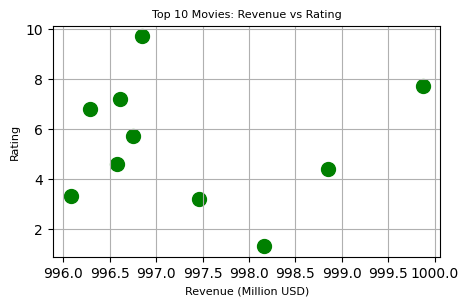

In [17]:
# Scatter Plot – Revenue vs Rating

# Select the top 10 movies with the highest revenue
top10_revenue = df.sort_values(by='Revenue_Million_USD', ascending=False).head(10)

plt.figure(figsize=(5, 3))  # Set figure size

plt.scatter(top10_revenue['Revenue_Million_USD'],
            top10_revenue['Rating'],
             color='brown',s=100, facecolor="green", edgecolor="green")  # specified s=10 to reduce the size of the data points(marker size) for visibility

plt.title('Top 10 Movies: Revenue vs Rating', fontsize=8)
plt.xlabel('Revenue (Million USD)', fontsize=8)
plt.ylabel('Rating', fontsize=8)

plt.grid(True)

plt.show()

# Business Insights

* A Top movie produced revenue of 997M$ got ~10 ratings
* High-rated movies do not always earn the highest revenue.
* Revenue depends on many factors, such as marketing, star cast, release timing, and audience interest.


df.sort_values(by='Rating', ascending=False) → Sorts the movies from highest rating to lowest rating.
.head(10) → Selects the top 10 highest-rated movies.
top_movies[['Movie_Title', 'Rating']] → Displays the selected movies and their ratings.
plt.figure(figsize=(10, 6)) → Creates a figure of size 10 × 6 inches.
plt.barh(top_movies['Movie_Title'], top_movies['Rating']) → Creates a horizontal bar chart where:
Y-axis: Movie titles
X-axis: Ratings
plt.gca().invert_yaxis() → Places the highest-rated movie at the top of the chart.
plt.tight_layout() → Ensures that long movie titles are fully visible.
plt.show() → Displays the graph.


               Movie_Title  Rating
769            Face Police    10.0
830           President Tv    10.0
33              Young That    10.0
951             Finish Bag    10.0
3763          Run Employee    10.0
3282                Let By    10.0
4037  Relationship Prepare    10.0
3036             Yard Fact    10.0
4306         Break Perhaps    10.0
4352        Mouth National    10.0


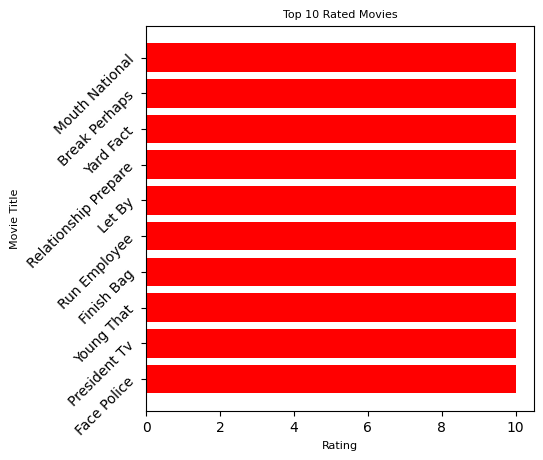

In [18]:
# Horizontal Bar Plot – Top Rated Movies

# Select top 10 rated movies
top_movies = df.sort_values(by='Rating', ascending=False).head(10)
print(top_movies[['Movie_Title', 'Rating']])

# Create a horizontal bar chart
plt.figure(figsize=(5, 5))  # Set figure size
plt.barh(top_movies['Movie_Title'], top_movies['Rating'], color='red')  # Y-axis: Movie Titles, X-axis: Ratings
plt.title('Top 10 Rated Movies', fontsize=8)  # Add title
plt.xlabel('Rating', fontsize=8)  # X-axis label
plt.ylabel('Movie Title', fontsize=8)  # Y-axis label
plt.yticks(rotation=45, )
plt.show()  # Display plot

# Business Insights

* The chart shows the top 10 highest-rated movies.
* These movies can be studied to understand what audiences enjoy most.
Their success can help guide future movie production.

#Conclusion

This project analyzed a movie ratings dataset using NumPy, Pandas, and Matplotlib to understand trends in movie ratings, budgets, revenues, genres, directors, and release years.

The statistical analysis showed that the average movie rating was 5.5, with a median rating of 5.5 and a standard deviation of 2.61, indicating that most movie ratings are fairly consistent with moderate variation.

The average production budget was $152.25 million, while the average revenue was $499.76 million. The higher average revenue compared to the average budget suggests that many movies in the dataset generated profits, although revenue varied considerably across movies.

The grouped analysis revealed that some genres and directors consistently achieved higher average ratings, indicating stronger audience preference. The year-wise analysis also showed how audience ratings changed over time.

The scatter plots demonstrated that higher production budgets do not always lead to higher audience ratings, and higher-rated movies do not necessarily earn the highest revenue. This indicates that factors such as story quality, direction, cast performance, marketing, and release strategy also play an important role in a movie's success.

Overall, this project demonstrates how Python libraries such as NumPy, Pandas, and Matplotlib can transform raw movie data into meaningful insights. These findings can help production companies make better decisions regarding genre selection, budget planning, director selection, and marketing strategies.




In [19]:
grouped_genre_rating=df.groupby('Genre')['Rating'].mean().round(2)
genre_rating=grouped_genre_rating.sort_values(ascending=False)
print(genre_rating)

Genre
Animation    5.62
Sci-Fi       5.61
Romance      5.56
Drama        5.55
Thriller     5.53
Adventure    5.51
Action       5.43
Comedy       5.43
Fantasy      5.43
Horror       5.36
Name: Rating, dtype: float64


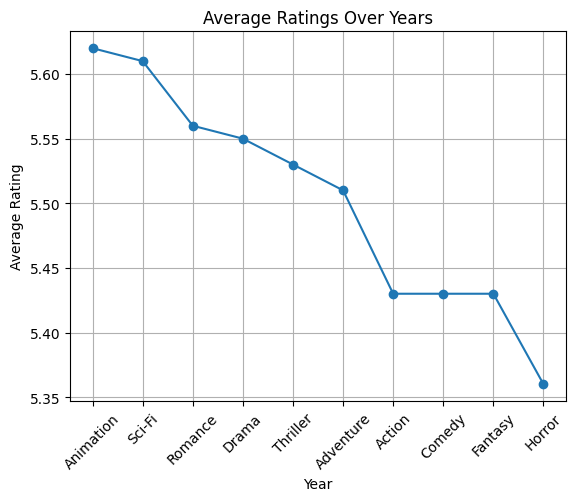

In [20]:
plt.plot(genre_rating.index, genre_rating.values, marker='o')
plt.title('Average Ratings Over Years')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [21]:
genre_rating=df.groupby('Genre')['Rating'].mean().round(2)
#genre_rating=np.sort(genre_rating)
print(genre_rating)

Genre
Action       5.43
Adventure    5.51
Animation    5.62
Comedy       5.43
Drama        5.55
Fantasy      5.43
Horror       5.36
Romance      5.56
Sci-Fi       5.61
Thriller     5.53
Name: Rating, dtype: float64


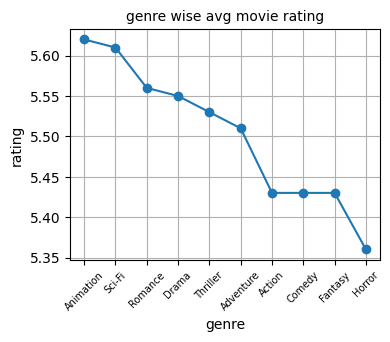

In [22]:
top_genre= genre_rating.sort_values(ascending=False)
plt.figure(figsize=(4,3))
plt.plot(top_genre.index, top_genre.values, marker='o')
plt.title("genre wise avg movie rating", fontsize=10)
plt.xlabel("genre", fontsize=10)
plt.ylabel("rating", fontsize=10)
plt.xticks(rotation=45, fontsize=7)
plt.grid(True)
plt.show()